In [224]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

%matplotlib notebook

In [12]:
# Definition of relu
def relu(x):
    y = np.zeros(np.size(x))
    y[x > 0] = x[x>0]
    return y

Text(0.5, 0, 'x')

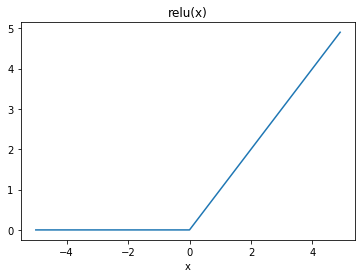

In [17]:
# Plot the relu
dx = 0.1
x = np.arange(-5, 5, dx)

y = relu(x)

plt.figure()
plt.plot(x, y)
plt.title('relu(x)')
plt.xlabel('x')

<IPython.core.display.Javascript object>


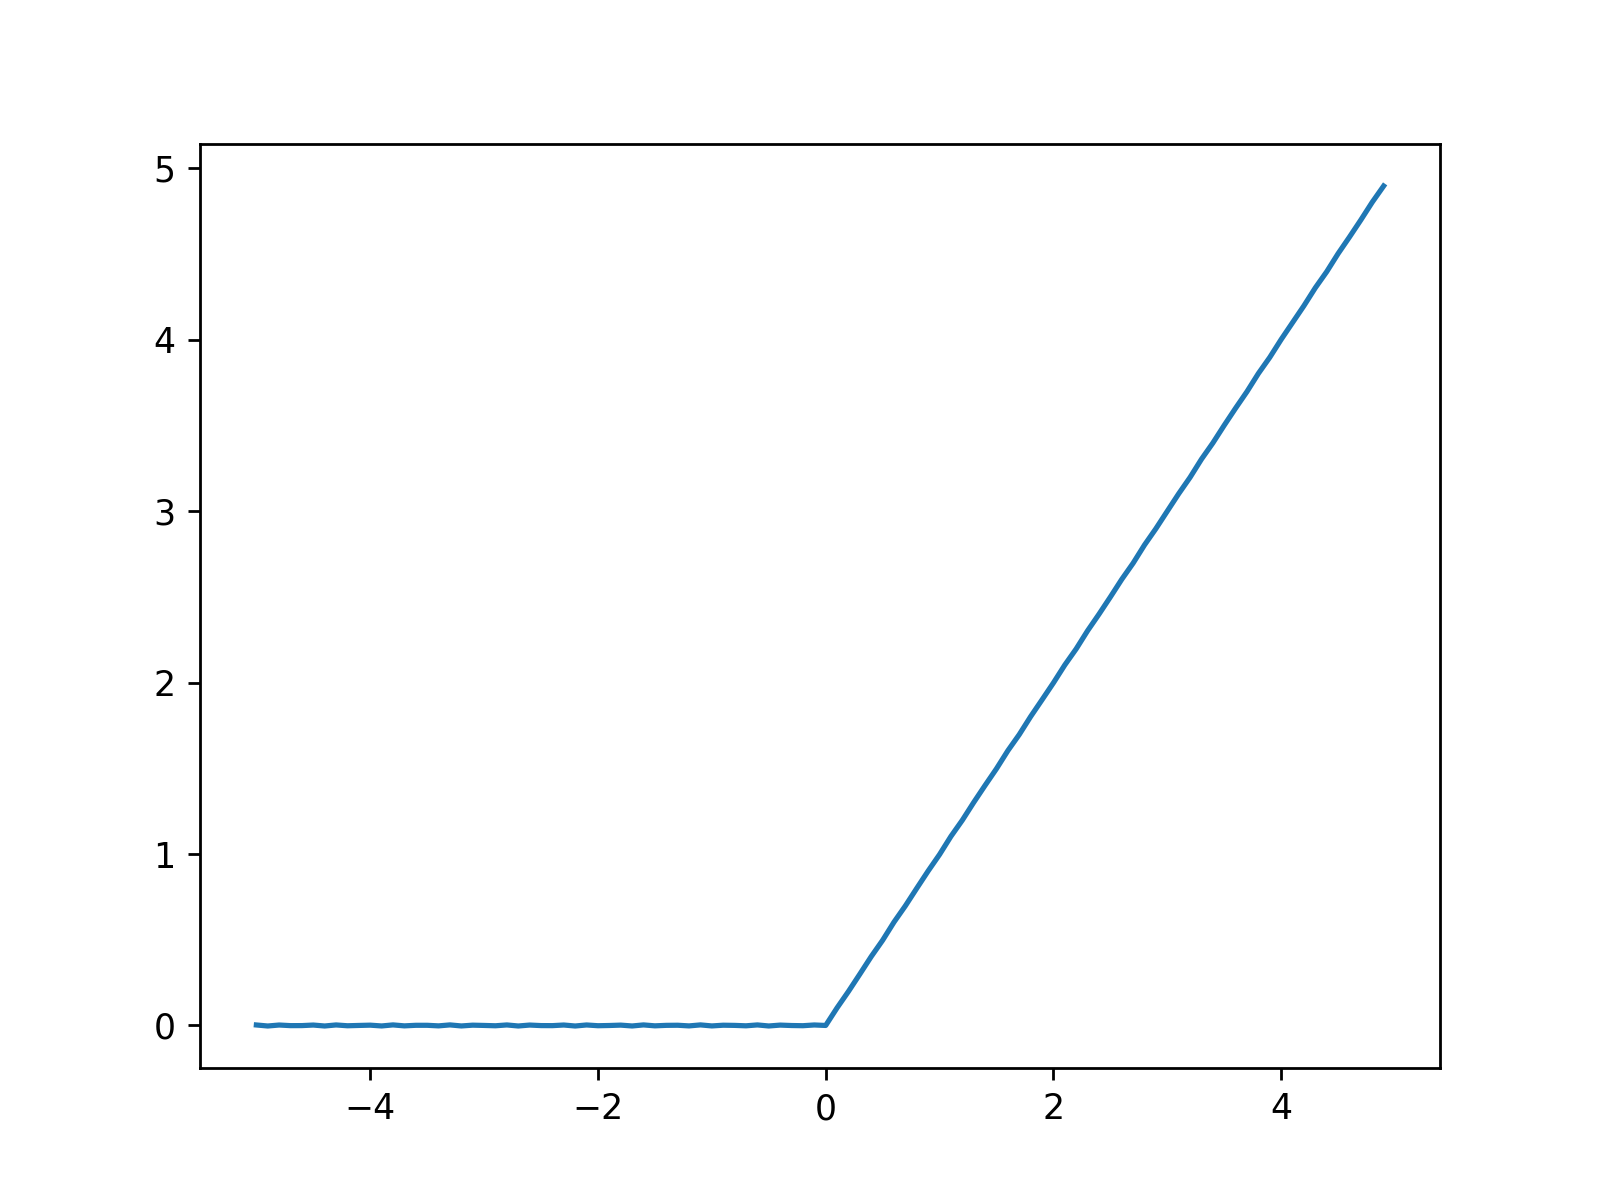

In [105]:
# Try to reconstruct relu from sine transform
dx = 0.1
x = np.arange(-5, 5, dx)

xi_max = 100
dxi = 0.001
epsilon = 1e-15
xi = np.arange(epsilon, xi_max, dxi)

sgn_approx = np.zeros(np.size(x))

for idx in range(0, len(x)):
    integrand = np.sin(xi*x[idx])/xi
    integral = np.trapz(integrand, x=xi)
    sgn_approx[idx] = integral
    
y_approx = x/2 + x/np.pi * sgn_approx

plt.figure()
plt.plot(x, y_approx)

1.0984910640281476
-0.0736405595953405
0.0026658234967517295
-5.4707531896581856e-05
7.131209793165818e-07
-6.4004927362360415e-09
4.189201017176583e-11
-2.086205353838795e-13
8.166266449611653e-16
-2.5780172391997656e-18
6.701374515331827e-21
-1.4591431087499165e-23
2.699774693411251e-26
-4.2969441732350145e-29
5.945145735037151e-32
-7.216205915202331e-35
7.746148346054061e-38
-7.405899270153679e-41


<IPython.core.display.Javascript object>


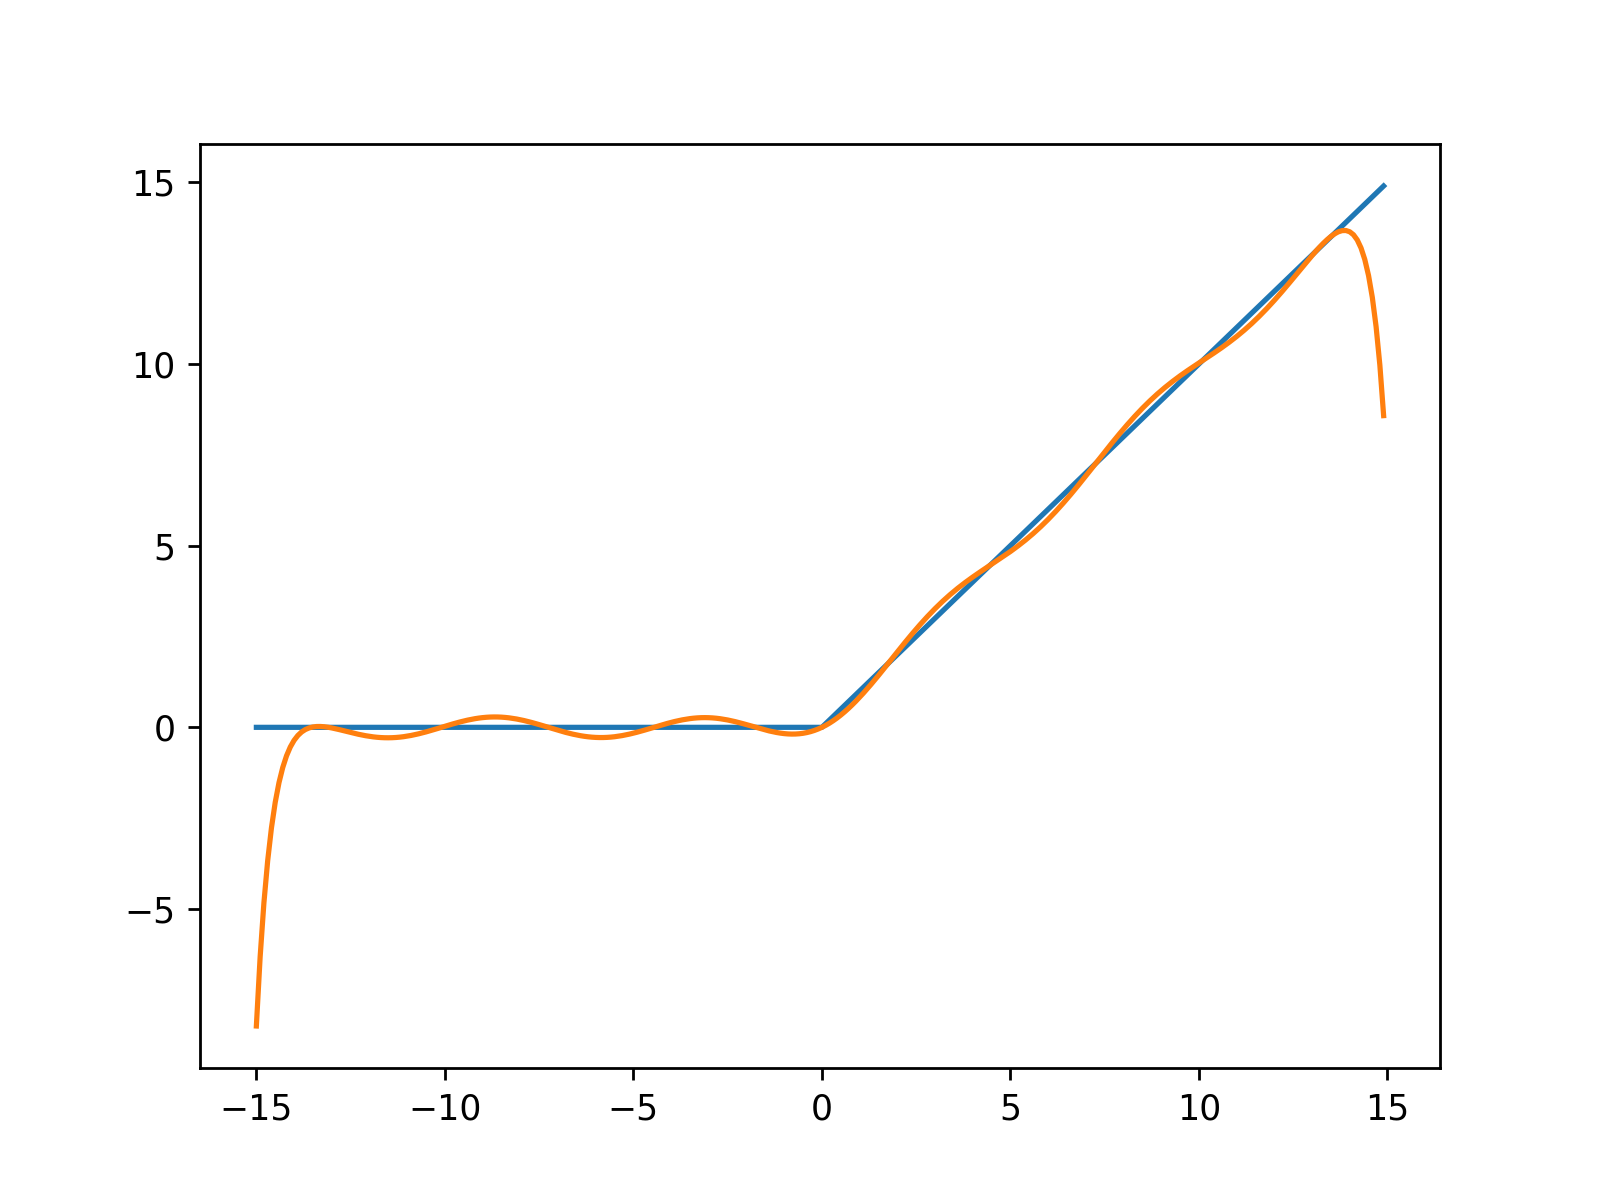

In [140]:
# Try to reconstruct relu from sine transform
dx = 0.1
x_max = 15
x = np.arange(-x_max, x_max, dx)
big_m = 18

summation = np.zeros(np.size(x))

for m in range(0, big_m):

    j = 2*m + 1
    power = j / (2*big_m + 3)
    numer = (-1)**m * (2*big_m + 3) ** power
    denom = np.math.factorial(2*m + 1) * (2*m + 1)
    
    alpha = numer / denom
    print(alpha)
    term = alpha * x ** j
    summation += term
    
y_approx = x/2 + x/np.pi * summation

plt.figure()
plt.plot(x, relu(x))
plt.plot(x, y_approx)

<IPython.core.display.Javascript object>


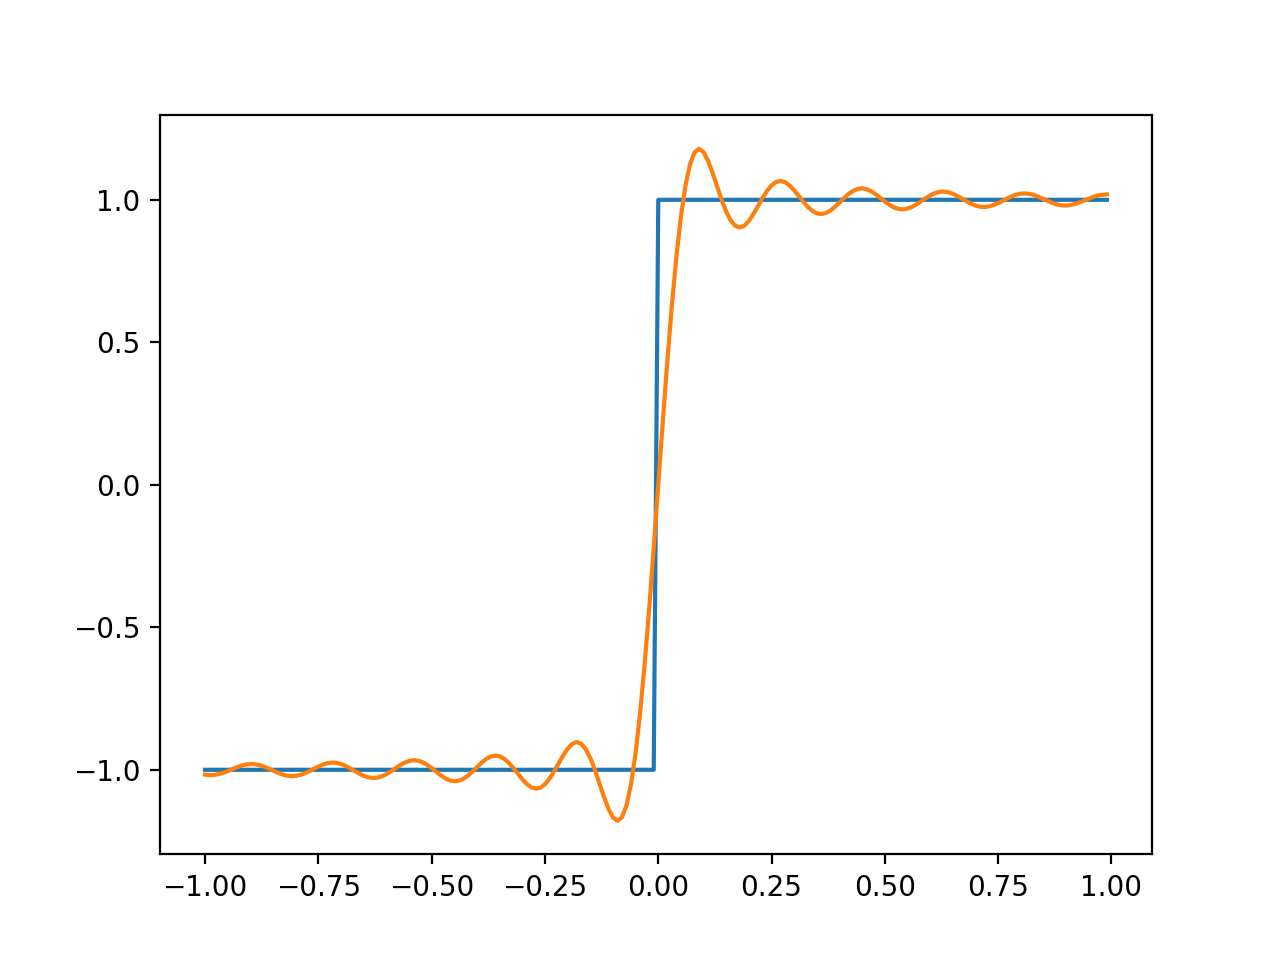

<IPython.core.display.Javascript object>


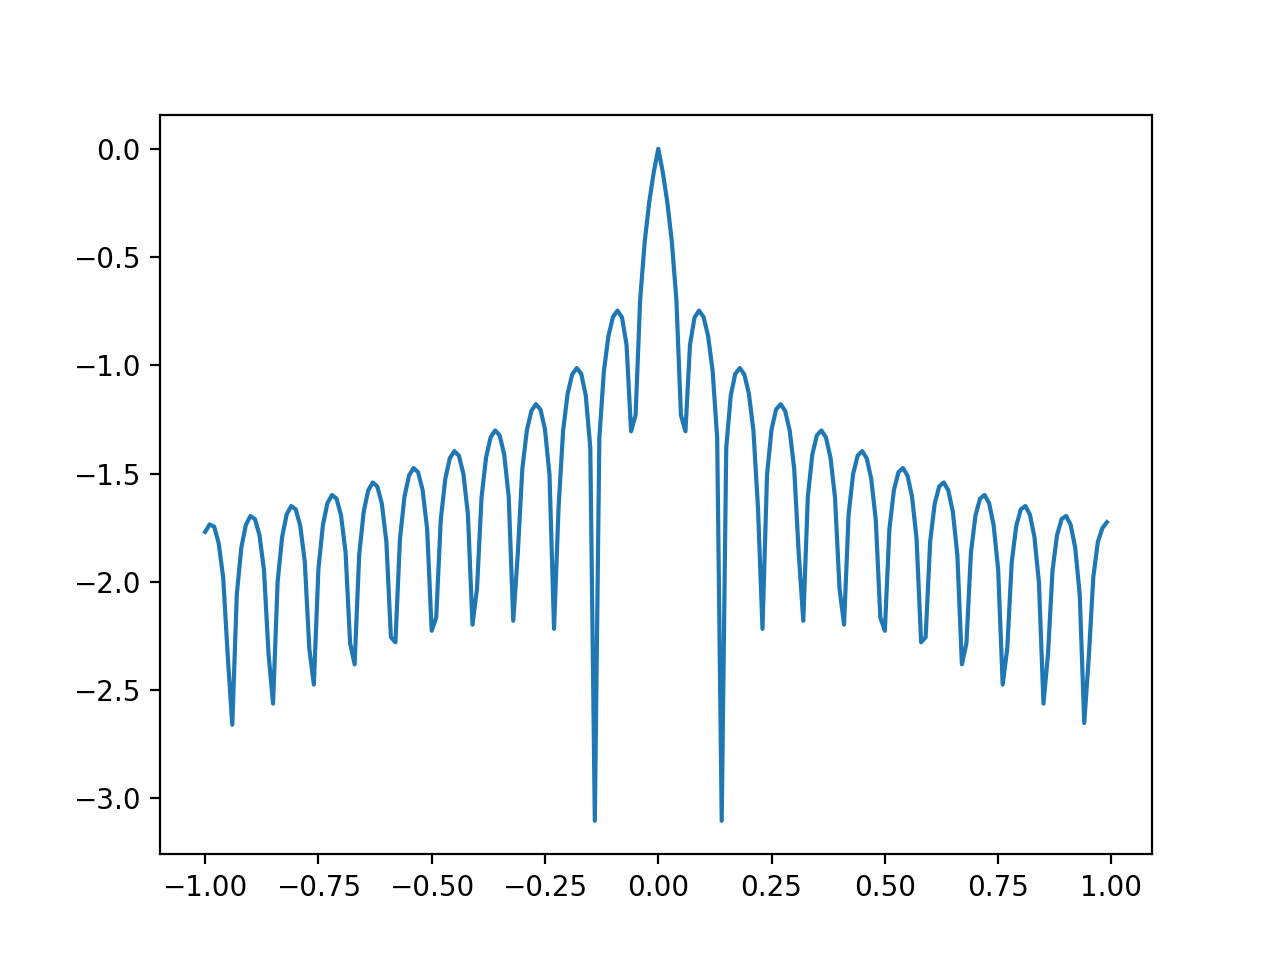

In [239]:
# Try to reconstruct sgn(x) from the summation
dx = 0.01
x_max = 1
x = np.arange(-x_max, x_max, dx)
big_m = 150
rho = 35

summation = np.zeros(np.size(x))

for m in range(0, big_m):

    j = 2*m + 1
    numer = (-1)**m * rho ** j
    denom = np.math.factorial(j) * j
    
    alpha = numer / denom
    term = alpha * x ** j
    summation += term
    
y_approx = 2/np.pi * summation

plt.figure()
plt.plot(x, np.sign(x))
plt.plot(x, y_approx)

error = np.sign(x) - y_approx

plt.figure()
plt.plot(x, np.log10(abs(error)))

<IPython.core.display.Javascript object>


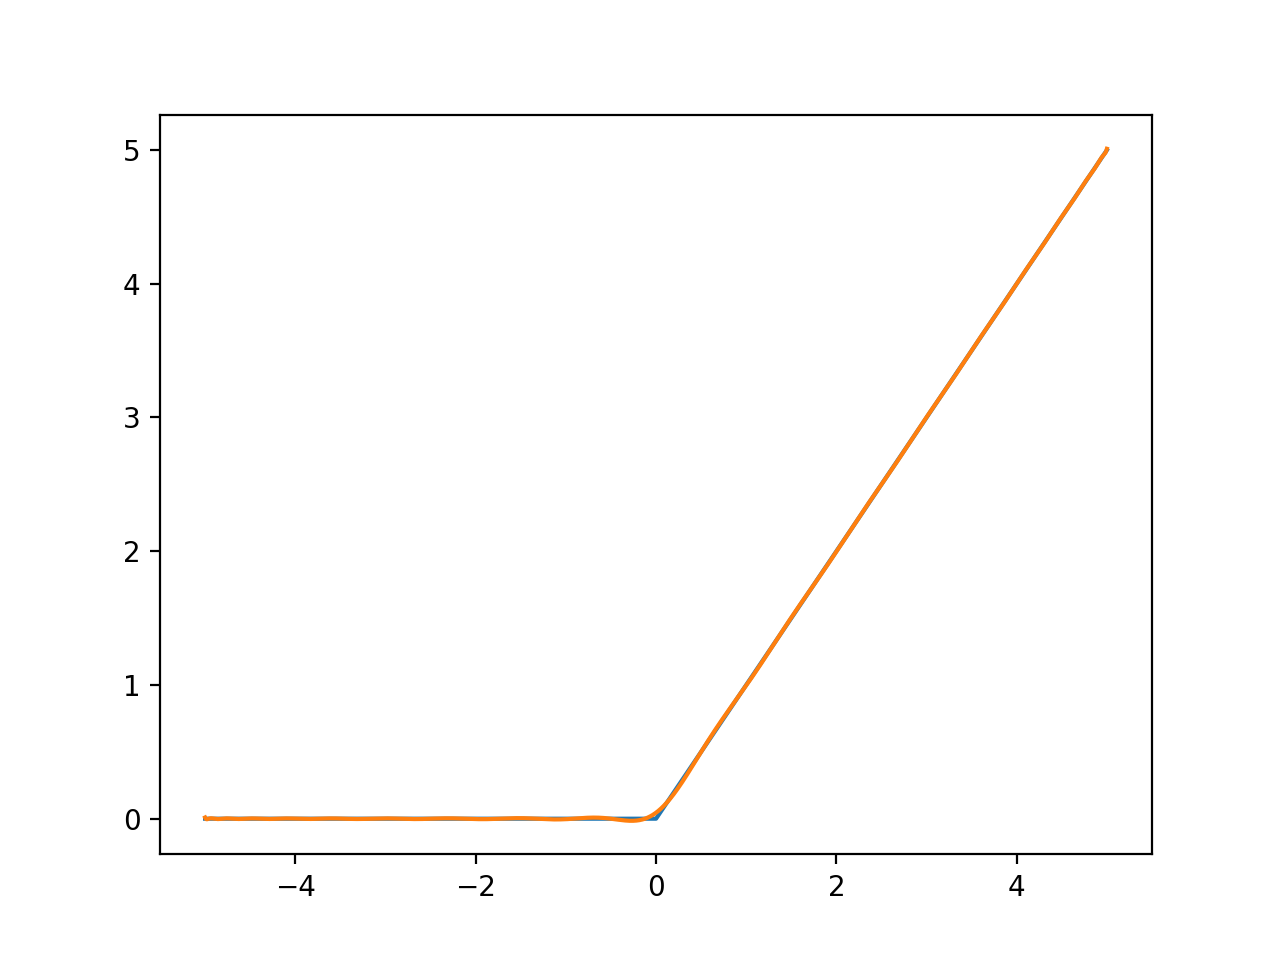

In [247]:
dx = 0.001
x_max = 5
x = np.arange(-x_max, x_max, dx)
y = relu(x)
warnings.simplefilter('ignore', np.RankWarning)

coefs = np.polyfit(x, y, 50)
p = np.poly1d(coefs)

y_approx = p(x)

plt.figure()
plt.plot(x, y)
plt.plot(x, y_approx)